# Eurosat Assignment

**Authors:** Jason Fan, Henry Sywulak-Herr
**Submission Date:** 4/5/2026 

## 1. Data Loading, Processing, and Exploration

### 1.1 Data Preparation

Visit the EuroSAT data description page and download the data. Perform basic exploratory data analysis, assessing the class distribution across the dataset and plotting one image from each class in a 2x5 grid.

Flatten the images into a 2D data matrix (n x p, where n is the number of samples and p is the number of pixels in each image). Load these and the labels into numpy arrays. Split the data into training (60%) and testing (40%) datasets, stratified on class labels (so that there is an equal percentage of each class type in each of the training and testing sets).

Lastly, create a grayscale version of this dataset. You will use this for the traditional machine learning models and the first couple of deep learning models.

In [1]:
import os
import zipfile
import requests
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.ndimage import rotate, zoom
import random

In [2]:
BASE_PATH = "./eurosat_files/"
ZIP_PATH = "./eurosat_files/eurosat.zip"

if os.path.exists(BASE_PATH):
    print("Eurosat data already downloaded")
else:
    os.makedirs(BASE_PATH, exist_ok=True)

    URL_EUROSAT = "https://zenodo.org/records/7711810/files/EuroSAT_MS.zip?download=1"

    print(f"Downloading from: {URL_EUROSAT}...")

    with requests.get(URL_EUROSAT, stream=True, timeout=30) as r:
        r.raise_for_status()
        with open(ZIP_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=8192):
                f.write(chunk)

    print("Download complete")

    print("Extracting files...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(BASE_PATH)

    print("Extraction complete")

Eurosat data already downloaded


In [3]:
CLASS_NAMES = os.listdir("./eurosat_files/EuroSAT_MS/")
print(CLASS_NAMES)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Load Images into Memmap

In [4]:
mmap_path = "./eurosat_files/images.dat"
label_path = "./eurosat_files/labels.npy"

if os.path.exists(mmap_path) and os.path.exists(label_path):
    print("Loading from cache...")
    labels = np.load(label_path)
    N = len(labels)
    images = np.memmap(mmap_path, dtype=np.float16, mode="r", shape=(N, 13, 64, 64))
    print(f"Loaded {N} images from cache")
else:
    # Count files first
    all_files, all_labels = [], []
    for label_idx, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(BASE_PATH, "EuroSAT_MS", class_name)
        files = sorted(glob.glob(os.path.join(class_path, "*.tif")))
        all_files.extend(files)
        all_labels.extend([label_idx] * len(files))

    N = len(all_files)
    print(f"Total images: {N}. Writing memmap...")

    images = np.memmap(mmap_path, dtype=np.float16, mode="w+", shape=(N, 13, 64, 64))
    for i, img_file in enumerate(all_files):
        with rasterio.open(img_file) as src:
            images[i] = src.read()
        if i % 2000 == 0:
            print(f"  {i}/{N}")
    images.flush()

    labels = np.array(all_labels)
    np.save(label_path, labels)
    print("Done. Cached to disk.")

Loading from cache...
Loaded 27000 images from cache


 Class Distribution & 2x5 Grid

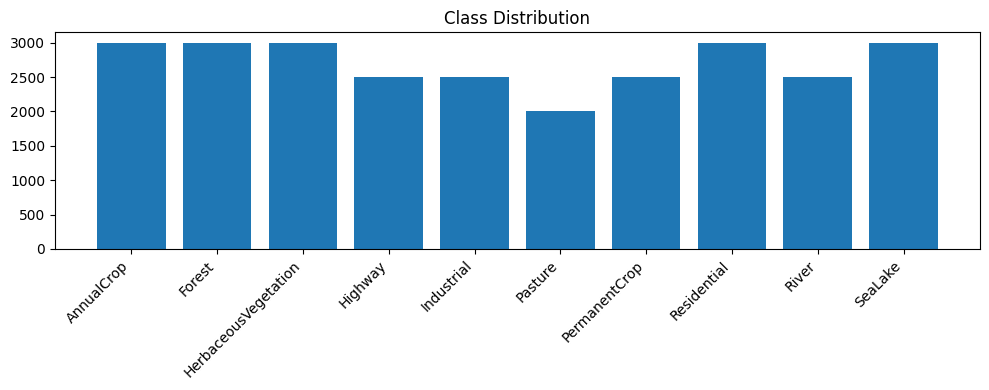

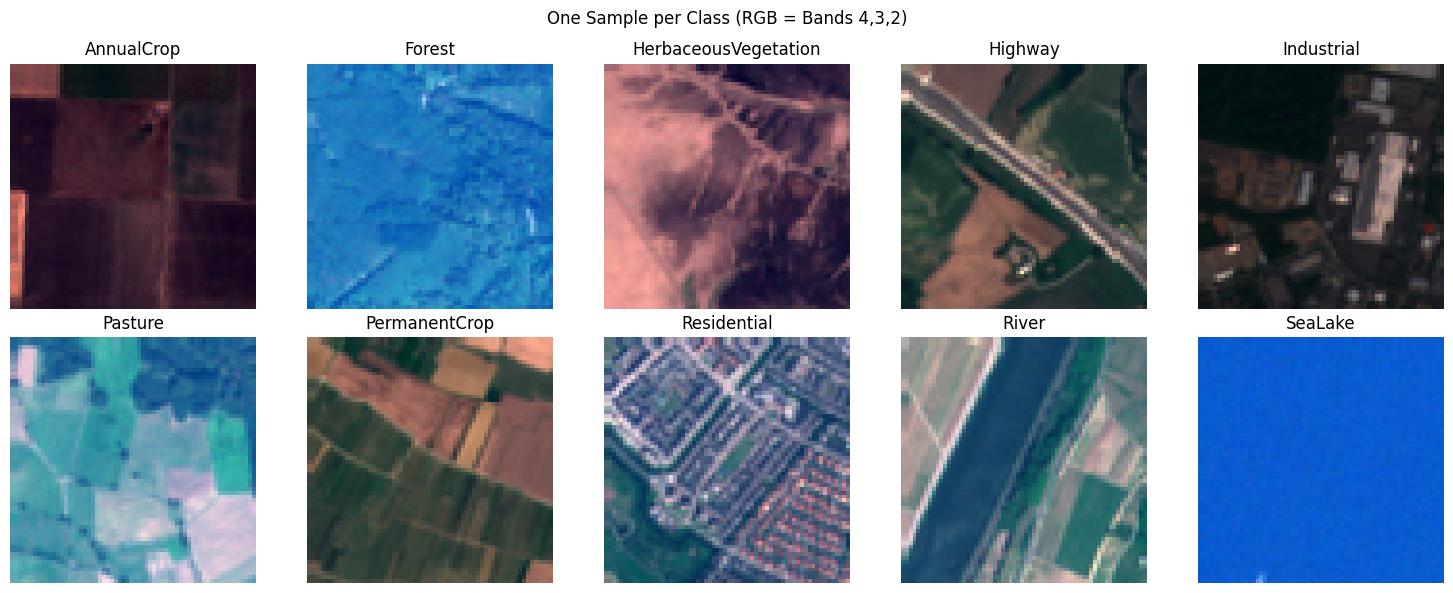

In [5]:
# Class distribution
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, counts)
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

# 2x5 grid — one image per class (RGB = bands 4,3,2 → index 3,2,1)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for idx, (ax, name) in enumerate(zip(axes.flat, CLASS_NAMES)):
    sample_idx = np.where(labels == idx)[0][0]
    rgb = images[sample_idx][[3, 2, 1], :, :].astype(float)
    rgb = np.moveaxis(rgb, 0, -1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    ax.imshow(rgb)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("One Sample per Class (RGB = Bands 4,3,2)")
plt.tight_layout()
plt.show()

Flatten, Split, Grayscale

In [6]:
N = len(images)

# Full 13-band flattened (N, 13*64*64)
X = images.reshape(N, -1).astype(np.float32)
y = labels

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Also keep image-shaped splits for deep learning later
idx_all = np.arange(N)
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.4, random_state=42, stratify=y
)
images_train = np.array(images[idx_train], dtype=np.float32)  # (N_train, 13, 64, 64)
images_test = np.array(images[idx_test], dtype=np.float32)  # (N_test,  13, 64, 64)

# Grayscale: mean of RGB bands (index 3,2,1)
gray_train = images_train[:, [3, 2, 1], :, :].mean(axis=1)  # (N_train, 64, 64)
gray_test = images_test[:, [3, 2, 1], :, :].mean(axis=1)

X_gray_train = gray_train.reshape(len(gray_train), -1).astype(np.float32)
X_gray_test = gray_test.reshape(len(gray_test), -1).astype(np.float32)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"X_gray_train: {X_gray_train.shape}, X_gray_test: {X_gray_test.shape}")

X_train: (16200, 53248), X_test: (10800, 53248)
X_gray_train: (16200, 4096), X_gray_test: (10800, 4096)


### 1.2 Data Augmentation

Apply data augmentation to increase the size of the dataset, appending the new samples to the original dataset. Indicate the augmentation approach(es) that you used and the total size of the new dataset. Again, plot three random images and a histogram of the label distribution across the full dataset.

Augmenting images (this may take a few minutes)...
Original train size: 16200, Augmented train size: 32400


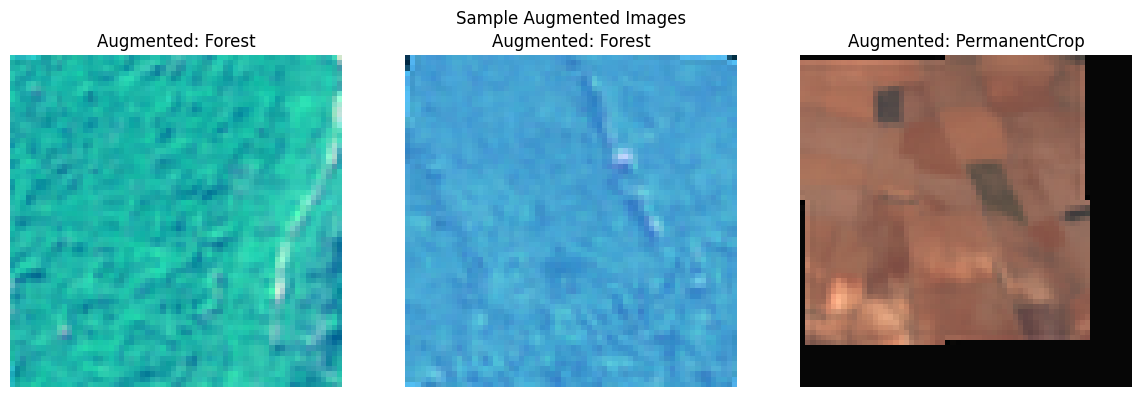

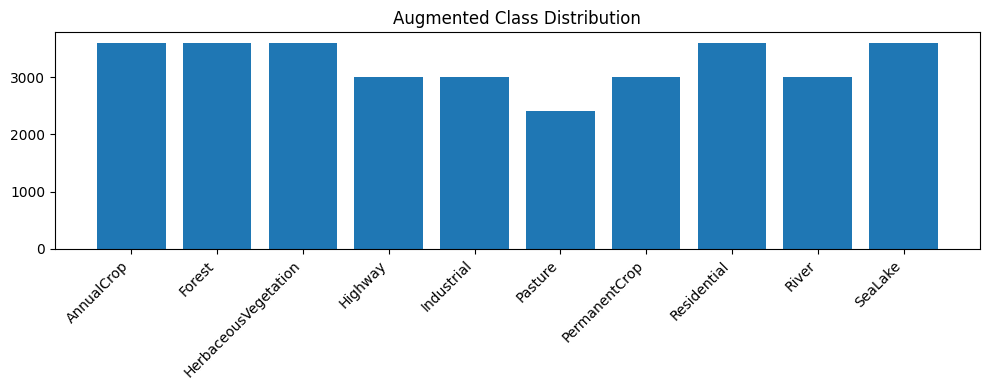

In [7]:


def augment_image(img):
    """img shape: (C, H, W)"""
    if random.random() > 0.5:
        img = img[:, :, ::-1].copy()
    angle = random.uniform(-30, 30)
    img = np.stack([rotate(img[c], angle, reshape=False) for c in range(img.shape[0])])
    factor = random.uniform(0.8, 1.2)
    zoomed = np.stack([zoom(img[c], factor) for c in range(img.shape[0])])
    h, w = zoomed.shape[1], zoomed.shape[2]
    start_h = max(0, (h - 64) // 2)
    start_w = max(0, (w - 64) // 2)
    zoomed = zoomed[:, start_h : start_h + 64, start_w : start_w + 64]
    if zoomed.shape[1] < 64 or zoomed.shape[2] < 64:
        pad_h = 64 - zoomed.shape[1]
        pad_w = 64 - zoomed.shape[2]
        zoomed = np.pad(zoomed, ((0, 0), (0, pad_h), (0, pad_w)))
    return zoomed


print("Augmenting images (this may take a few minutes)...")
aug_images = np.stack([augment_image(img) for img in images_train])
aug_labels = y_train.copy()

images_aug = np.concatenate([images_train, aug_images], axis=0)
labels_aug = np.concatenate([y_train, aug_labels], axis=0)

print(
    f"Original train size: {len(images_train)}, Augmented train size: {len(images_aug)}"
)

# Plot 3 random augmented images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax in axes:
    i = random.randint(len(images_train), len(images_aug) - 1)
    rgb = images_aug[i][[3, 2, 1]].astype(float)
    rgb = np.moveaxis(rgb, 0, -1)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    ax.imshow(rgb)
    ax.set_title(f"Augmented: {CLASS_NAMES[labels_aug[i]]}")
    ax.axis("off")
plt.suptitle("Sample Augmented Images")
plt.tight_layout()
plt.show()

# Augmented label distribution
plt.figure(figsize=(10, 4))
plt.bar(CLASS_NAMES, np.bincount(labels_aug))
plt.xticks(rotation=45, ha="right")
plt.title("Augmented Class Distribution")
plt.tight_layout()
plt.show()

## 2. Traditional Machine Learning

For this section, focus on three categories: "Forest (F)", "Residential (R)", and "Industrial (I)". Make sure to subset the grayscale dataset, selecting only these three classes.

### 2.1 Binary Support Vector Machine

Implement three binary SVM classifiers (use a linear kernel and default parameters) to classify [F vs R], [F vs I], and [R vs I]. Report the accuracy of each classifier, plot their ROC curves, calculate the AUCs, and show one image that is mis-classified by each classifier, including both the predicted label and the ground truth.

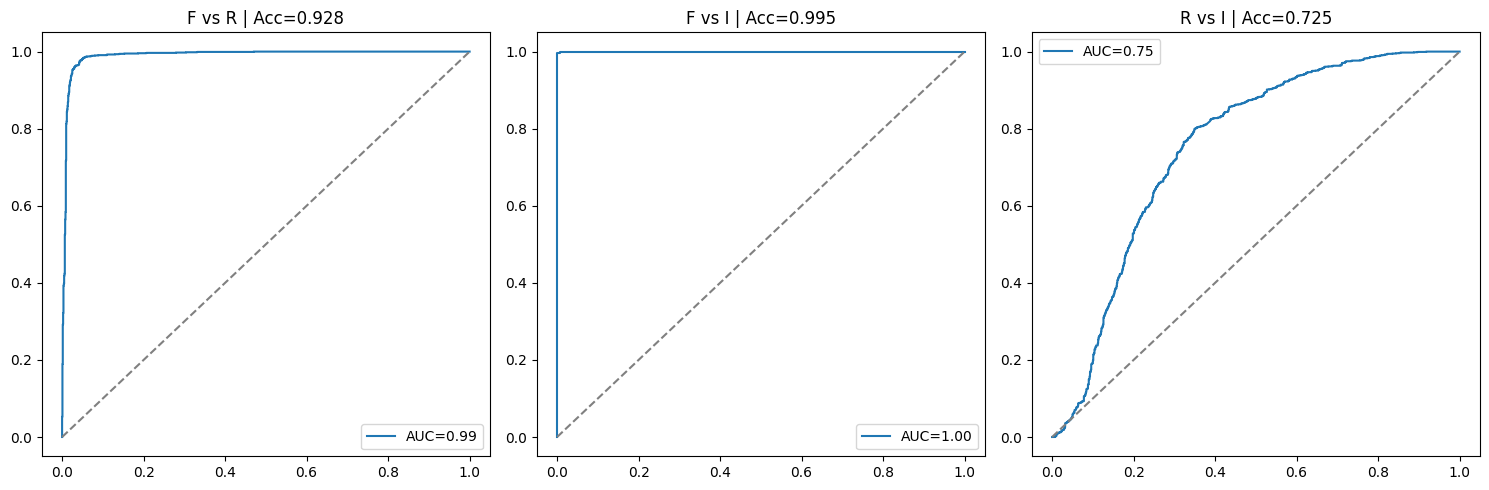

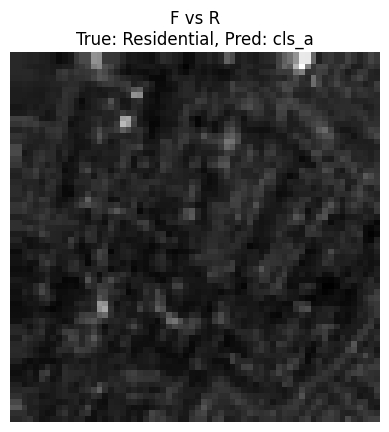

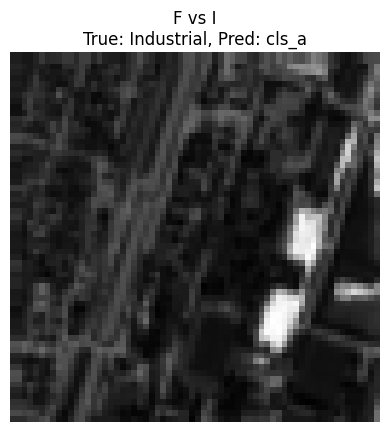

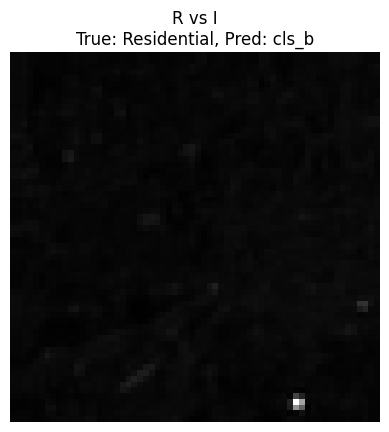

In [8]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.pipeline import Pipeline

# Subset to F, R, I
class_map = {"Forest": 1, "Residential": 7, "Industrial": 4}
target_labels = [1, 7, 4]
label_names = {1: "Forest", 4: "Industrial", 7: "Residential"}

mask_train = np.isin(y_train, target_labels)
mask_test = np.isin(y_test, target_labels)
X_tri_train = X_gray_train[mask_train]
y_tri_train = y_train[mask_train]
X_tri_test = X_gray_test[mask_test]
y_tri_test = y_test[mask_test]

pairs = [(1, 7, "F vs R"), (1, 4, "F vs I"), (7, 4, "R vs I")]
binary_models = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (cls_a, cls_b, title) in zip(axes, pairs):
    mask_tr = np.isin(y_tri_train, [cls_a, cls_b])
    mask_te = np.isin(y_tri_test, [cls_a, cls_b])
    Xtr, ytr = X_tri_train[mask_tr], (y_tri_train[mask_tr] == cls_a).astype(int)
    Xte, yte = X_tri_test[mask_te], (y_tri_test[mask_te] == cls_a).astype(int)

    clf = Pipeline(
        [("scaler", StandardScaler()), ("svm", SVC(kernel="linear", probability=True))]
    )
    clf.fit(Xtr, ytr)
    binary_models[(cls_a, cls_b)] = clf

    y_prob = clf.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, y_prob)
    roc_auc = auc(fpr, tpr)
    acc = accuracy_score(yte, clf.predict(Xte))

    ax.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set_title(f"{title} | Acc={acc:.3f}")
    ax.legend()
plt.tight_layout()
plt.show()

# Show one misclassified image per classifier
for (cls_a, cls_b, title), clf in zip(pairs, binary_models.values()):
    mask_te = np.isin(y_tri_test, [cls_a, cls_b])
    Xte, yte_raw = X_tri_test[mask_te], y_tri_test[mask_te]
    yte = (yte_raw == cls_a).astype(int)
    y_pred = clf.predict(Xte)
    misclassified = np.where(y_pred != yte)[0]
    if len(misclassified):
        idx = misclassified[0]
        plt.imshow(Xte[idx].reshape(64, 64), cmap="gray")
        plt.title(
            f"{title}\nTrue: {label_names[yte_raw[idx]]}, Pred: {'cls_a' if y_pred[idx] == 1 else 'cls_b'}"
        )
        plt.axis("off")
        plt.show()

### 2.2 Multiclass, Majority-Vote SVM

Combine the three SVM models trained in the previous section to create a three-class classifier. The combined model will apply each one of the 3 classifiers on the testing data and will apply majority voting to decide the final class of the test sample. Again, calculate the accuracy, ROC, and AUC, and show a mis-classified image from each class, including both the predicted label and the ground truth.

OVO Accuracy: 0.7753


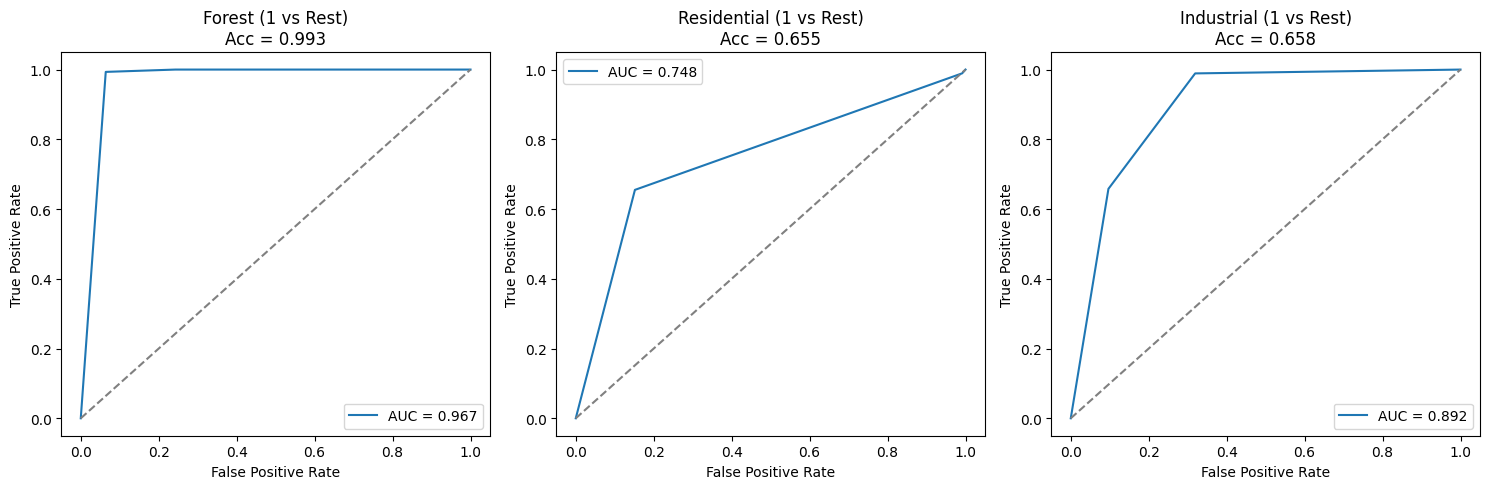

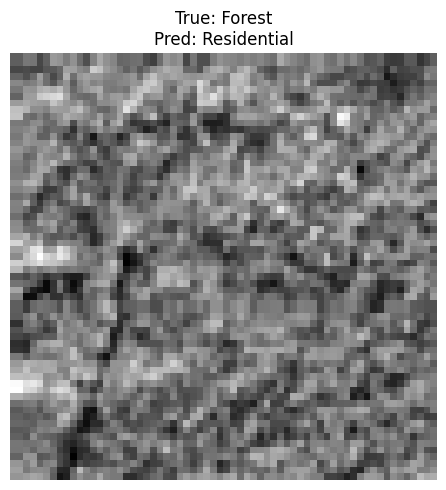

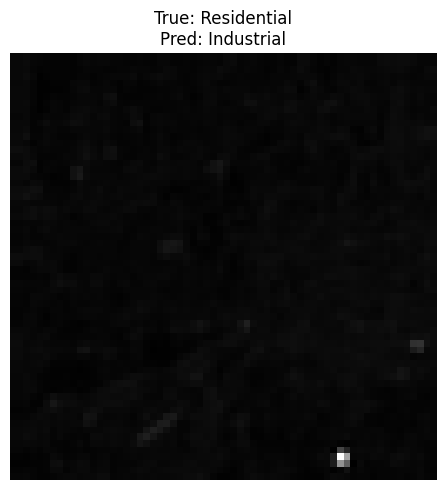

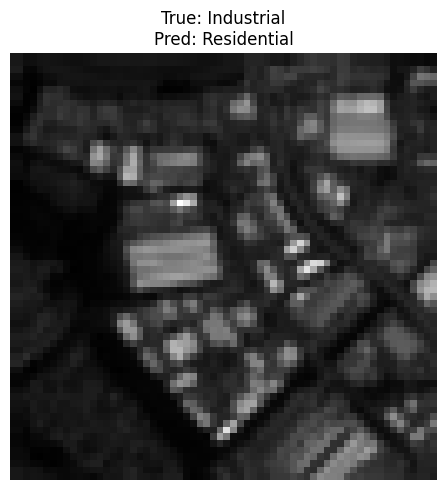

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_curve, auc


def ovo_predict(X, binary_models, target_labels):
    preds = []
    vote_scores = []  # store vote counts for ROC

    for x in X:
        votes = {label: 0 for label in target_labels}

        for (cls_a, cls_b), clf in binary_models.items():
            pred = clf.predict(x.reshape(1, -1))[0]
            winner = cls_a if pred == 1 else cls_b
            votes[winner] += 1

        # store prediction
        preds.append(max(votes, key=votes.get))

        # store normalized vote scores (for ROC)
        total_votes = sum(votes.values())
        vote_scores.append([votes[label] / total_votes for label in target_labels])

    return np.array(preds), np.array(vote_scores)


# Run prediction
y_pred_ovo, y_score_ovo = ovo_predict(X_tri_test, binary_models, target_labels)

# Accuracy
acc_ovo = accuracy_score(y_tri_test, y_pred_ovo)
print(f"OVO Accuracy: {acc_ovo:.4f}")


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (ax, cls_label) in enumerate(zip(axes, target_labels)):
    y_bin = (y_tri_test == cls_label).astype(int)
    y_score = y_score_ovo[:, idx]

    # ROC
    fpr, tpr, _ = roc_curve(y_bin, y_score)
    roc_auc = auc(fpr, tpr)

    # ✅ Per-class accuracy
    mask = y_tri_test == cls_label
    cls_acc = accuracy_score(y_tri_test[mask], y_pred_ovo[mask])

    ax.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "--", color="gray")

    ax.set_title(f"{label_names[cls_label]} (1 vs Rest)\nAcc = {cls_acc:.3f}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
plt.show()

for cls_label in target_labels:
    mask_cls = y_tri_test == cls_label

    y_pred_cls = y_pred_ovo[mask_cls]
    y_true_cls = y_tri_test[mask_cls]
    X_cls = X_tri_test[mask_cls]

    misclassified = np.where(y_pred_cls != y_true_cls)[0]

    if len(misclassified) > 0:
        idx = misclassified[0]

        plt.figure(figsize=(5, 5))
        plt.imshow(X_cls[idx].reshape(64, 64), cmap="gray")
        plt.title(
            f"True: {label_names[y_true_cls[idx]]}\n"
            f"Pred: {label_names[y_pred_cls[idx]]}"
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()

### 2.3 Multiclass Random Forest

Train a Random-Forest classifier to classify the data into one of the three classes. Use the training data. Apply the trained model on testing data. Report the accuracy, plot the confusion matrix, and print a mis-classified image from each class, including both the predicted label and the ground truth.

RF Accuracy: 0.9167647058823529


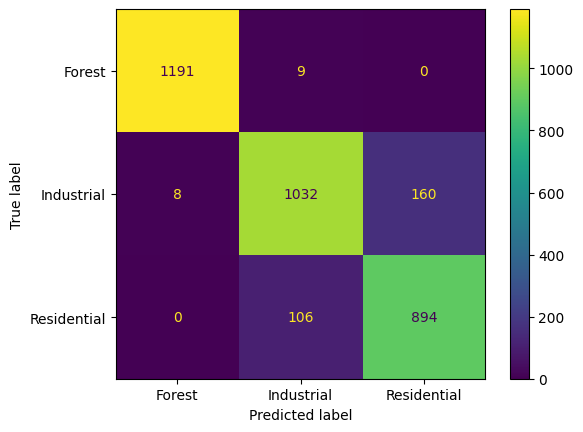

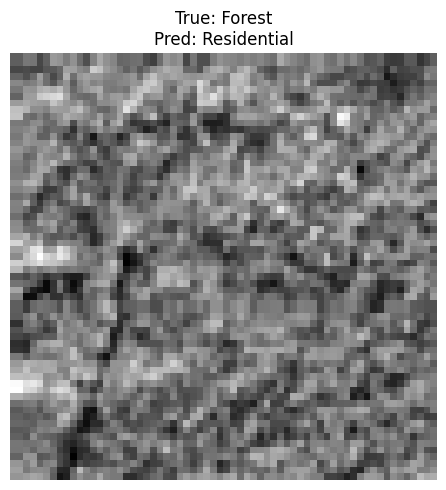

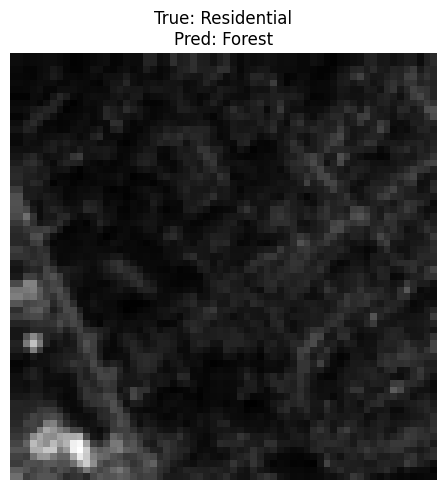

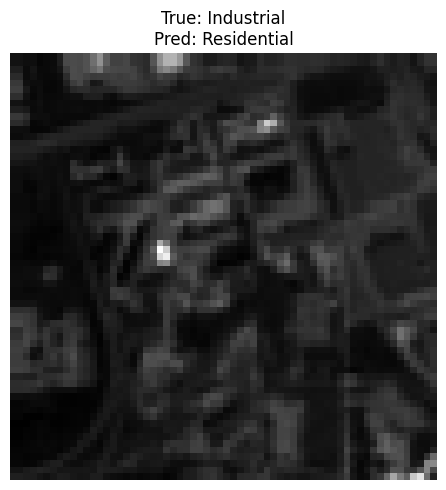

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ]
)
rf.fit(X_tri_train, y_tri_train)
y_pred_rf = rf.predict(X_tri_test)

print("RF Accuracy:", accuracy_score(y_tri_test, y_pred_rf))

cm = confusion_matrix(y_tri_test, y_pred_rf, labels=target_labels)
disp = ConfusionMatrixDisplay(
    cm, display_labels=["Forest", "Industrial", "Residential"]
)
disp.plot()
plt.show()

for cls_label in target_labels:
    mask_cls = y_tri_test == cls_label
    y_pred_cls = y_pred_rf[mask_cls]
    y_true_cls = y_tri_test[mask_cls]
    X_cls = X_tri_test[mask_cls]

    misclassified = np.where(y_pred_cls != y_true_cls)[0]

    if len(misclassified) > 0:
        idx = misclassified[0]
        plt.figure(figsize=(5, 5))
        plt.imshow(X_cls[idx].reshape(64, 64), cmap="gray")
        plt.title(
            f"True: {label_names[y_true_cls[idx]]}\n"
            f"Pred: {label_names[y_pred_cls[idx]]}"
        )
        plt.axis("off")
        plt.tight_layout()
        plt.show()

## 3. Deep Learning

For this section, we will use the full range of possible land cover categories, so do not filter the training and testing datasets for only certain labels.

In [11]:
from tensorflow.python.keras.utils.all_utils import to_categorical

# Encode labels 0–9 sequentially
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
y_train_cat = to_categorical(y_train_enc, 10)
y_test_cat = to_categorical(y_test_enc, 10)

### 3.1 Greyscale Images

For this section, use the same greyscale images that you used in the traditional machine learning section.

#### 3.1.1 Single-Layer Neural Network

Implement a first deep learning model using a fully connected network with a single fully connected layer (i.e., input layer + fully connected layer as the output layer). Visualize the network architecture. (Refer to https://faroit.com/keras-docs/2.0.8/visualization/ to see the import command and function needed to visualize the architecture.) Calculate classification accuracy on the test data. (Hint: what kind of pre-processing might be necessary so that this model and the subsequent ones can handle categorical labels? Why?)

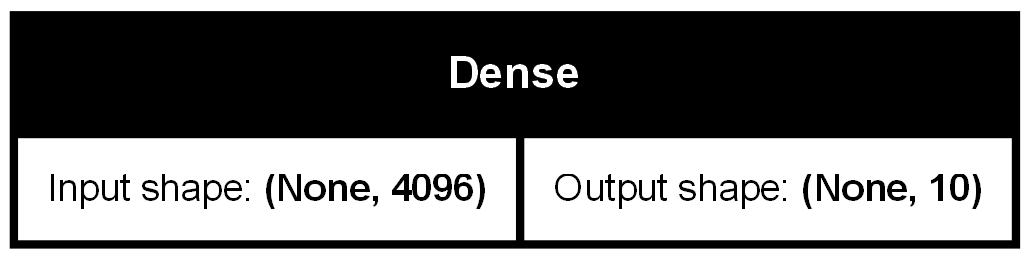

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1292 - loss: 2.2577 - val_accuracy: 0.1469 - val_loss: 2.2419
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1612 - loss: 2.2083 - val_accuracy: 0.1682 - val_loss: 2.1896
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1842 - loss: 2.1725 - val_accuracy: 0.2420 - val_loss: 2.1583
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2086 - loss: 2.1437 - val_accuracy: 0.2211 - val_loss: 2.1344
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2327 - loss: 2.1208 - val_accuracy: 0.2795 - val_loss: 2.1135
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2440 - loss: 2.1033 - val_accuracy: 0.2250 - val_loss: 2.0985
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2595 - loss: 2.0831 - val_accuracy: 0.2783 - val_loss: 2.0920
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2614 - loss: 2.0687 - val_accuracy: 0.

In [12]:
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
from IPython.display import Image

X_gray_train_norm = X_gray_train / X_gray_train.max()
X_gray_test_norm = X_gray_test / X_gray_test.max()

model1 = Sequential([Input(shape=(64 * 64,)), Dense(10, activation="softmax")])

plot_model(model1, to_file="model1.png", show_shapes=True)
display(Image("model1.png"))

model1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model1.fit(
    X_gray_train_norm,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_gray_test_norm, y_test_cat),
)
_, acc1 = model1.evaluate(X_gray_test_norm, y_test_cat)
print(f"Model 1 Accuracy: {acc1:.4f}")

#### 3.1.2 Two-Layer Neural Network

Implement a second deep learning model adding an additional fully connected hidden layer (with an arbitrary number of nodes) to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. How did adding an additional hidden layer affect your model's performance? Why might additional hidden layers improve or potentially worsen accuracy?

**Answer:** Classification accuracy increased approximately 2-3 percentage points with the addition of a 512-neuron hidden layer, though this improvement could be due to stochastic effects during training. A hidden layer allows the neural network to recognize more complex patterns within the input dataset and refine its categorization predictions. However, models with more hidden layers with greater numbers of nodes also require more computation resources/time to train, reduce the interpretability of the model itself due to this added complexity, and typically require larger training datasets in order to achieve a satisfactory level of generalizability. 

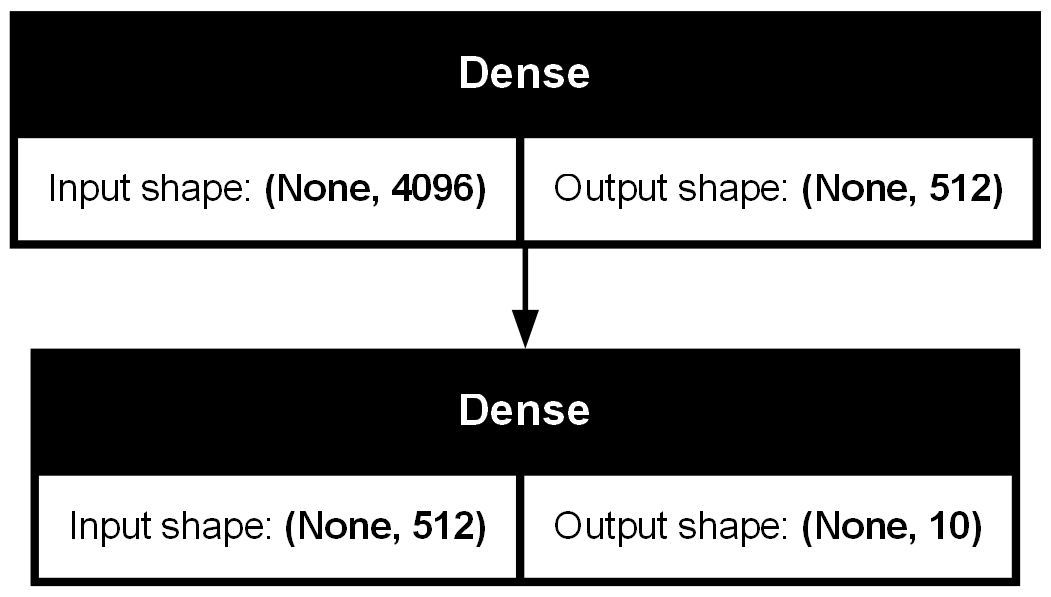

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1432 - loss: 2.2214 - val_accuracy: 0.2173 - val_loss: 2.1454
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2281 - loss: 2.0855 - val_accuracy: 0.2514 - val_loss: 2.0183
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2688 - loss: 1.9642 - val_accuracy: 0.3087 - val_loss: 1.9150
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.2919 - loss: 1.8835 - val_accuracy: 0.2670 - val_loss: 1.8830
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2910 - loss: 1.8514 - val_accuracy: 0.2820 - val_loss: 1.8899
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2960 - loss: 1.8334 - val_accuracy: 0.2942 - val_loss: 1.8272
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3077 - loss: 1.8080 - val_accuracy: 0.3063 - val_loss: 1.8042
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3163 - loss: 1.7876 - val_accu

In [13]:
model2 = Sequential(
    [
        Input(shape=(64 * 64,)),
        Dense(512, activation="relu"),
        Dense(10, activation="softmax"),
    ]
)

plot_model(model2, to_file="model2.png", show_shapes=True)
display(Image("model2.png"))

model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

model2.fit(
    X_gray_train_norm,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_gray_test_norm, y_test_cat),
)
_, acc2 = model2.evaluate(X_gray_test_norm, y_test_cat)
print(f"Model 2 Accuracy: {acc2:.4f}")

#### 3.1.3 Four-Layer Neural Network with Dropout

Implement a third deep learning model adding two additional fully connected hidden layers (with arbitrary number of nodes) for a total of four, as well as drop-out layers to the previous model. Visualize the network architecture. Calculate classification accuracy on the test data. What did you observe about the impact of dropout layers on the model's performance? Explain how dropout helps in model training and under what circumstances it might be more or less effective.

**Answer:** Dropout layers with a rate of 0.5 had a negative impact on model performance - classification accuracy of around 19-21% - while lowering this rate to 0.3 for both layers improved prediction accuracy to around 30%. Dropout is helpful when used after dense layers by forcing a neural network to randomly disable neurons during testing. This forces the neural network to learn redundant representations of the data and prevent them from co-adapting (when neurons in subsequent layers begin to extract the same or similar features within the data). This comes with potential trade-offs with low-complexity neural networks, since the total number of neurons being utilized at each step of the model is reduced where dropout is applied and could possibly contribute to underfitting. This reduction in complexity is likely why a dropout rate of 0.3 worked better for this model than a rate of 0.5.

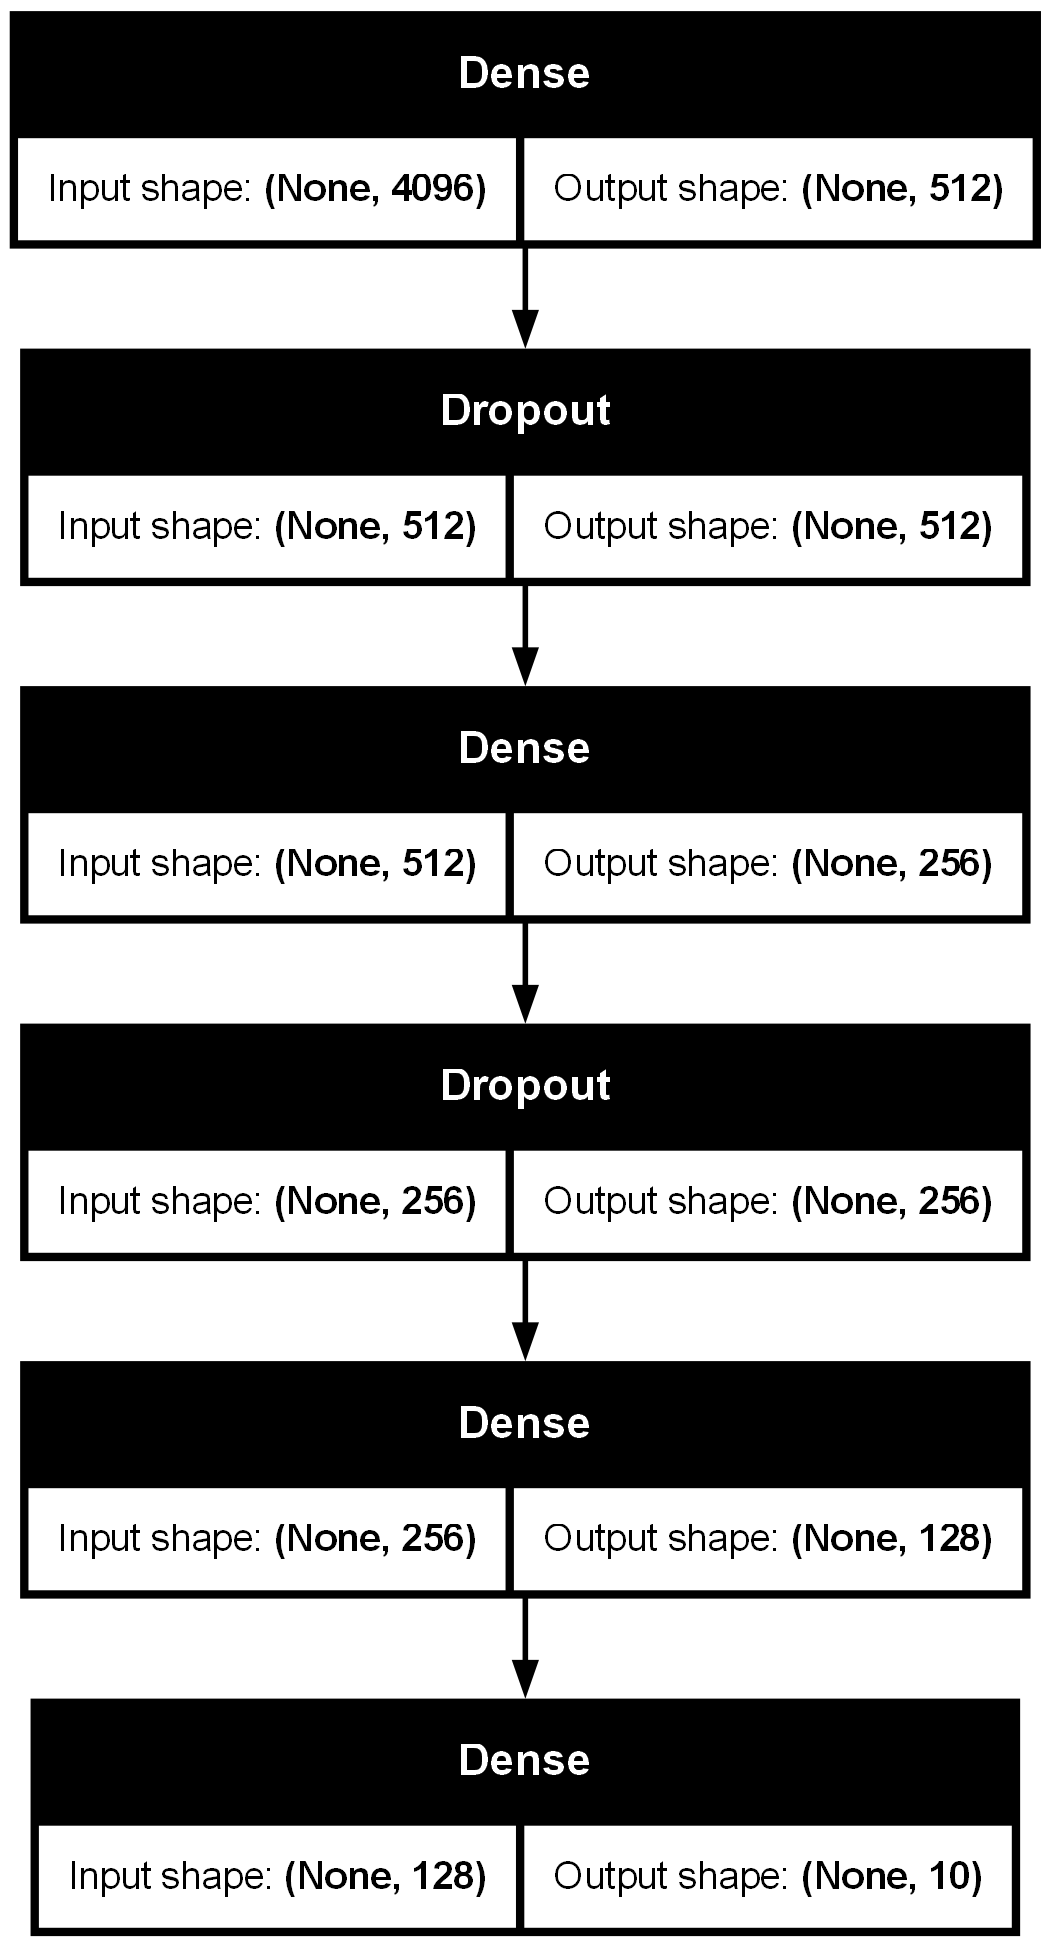

Epoch 1/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.1638 - loss: 2.1886 - val_accuracy: 0.2744 - val_loss: 1.9413
Epoch 2/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2574 - loss: 1.9284 - val_accuracy: 0.2545 - val_loss: 1.8898
Epoch 3/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2883 - loss: 1.8449 - val_accuracy: 0.2407 - val_loss: 2.0762
Epoch 4/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3070 - loss: 1.8004 - val_accuracy: 0.3146 - val_loss: 1.7543
Epoch 5/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3194 - loss: 1.7737 - val_accuracy: 0.2611 - val_loss: 1.9322
Epoch 6/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3309 - loss: 1.7524 - val_accuracy: 0.2105 - val_loss: 2.2299
Epoch 7/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3298 - loss: 1.7451 - val_accuracy: 0.2469 - val_loss: 2.0086
Epoch 8/10
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3387 - loss: 1.7309 - val_accu

In [14]:
from tensorflow.keras.layers import Dropout

model3 = Sequential(
    [
        Input(shape=(64 * 64,)),
        Dense(512, activation="relu"),
        Dropout(0.3),
        Dense(256, activation="relu"),
        Dropout(0.3),
        Dense(128, activation="relu"),
        Dense(10, activation="softmax"),
    ]
)

plot_model(model3, to_file="model3.png", show_shapes=True)
display(Image("model3.png"))

model3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model3.fit(
    X_gray_train_norm,
    y_train_cat,
    epochs=10,
    batch_size=64,
    validation_data=(X_gray_test_norm, y_test_cat),
)
_, acc3 = model3.evaluate(X_gray_test_norm, y_test_cat)
print(f"Model 3 Accuracy: {acc3:.4f}")

#### 3.1.4 Model Comparison and Ensemble

Compare models one through three. Which network had the most parameters to learn, and by what margin? Which model was the "best"? Why? For each model, what is the impact of increasing the number of training epochs?

Implement an ensemble model that incorporates the predictions of models one through three. Calculate its classification accuracy on the test data. How does this compare to the accuracies of the three individual models? Describe the ensemble approach you implemented. Why might ensembling improve model accuracy compared to the individual models?

**Answer:** Model 3 had the most parameters (2,263,178 parameters), which was 1.08 times the parameter count of Model 2 (2,102,794 parameters) and over 55 times that of Model 1 (40,970). Either Model 2 or Model 3 could be the better model, as both have classification accuracies hovering broadly around 30%, while Model 1 generally performs worse at around 26-28% accuracy.Increasing the number of training epochs generally improves model performance by 1-4 percentage points across all three models, though the greatest impact was in Model 2 with a hidden layer but no dropout (improvement to 34% accuracy).

The ensemble model results in a roughly average prediction accuracy of 28-30% between all three models. This is likely due to how the chosen process takes the prediction probabilities of each class for each image and averages them across all three models. The emsemble prediction taken is the class with the greatest averaged prediction probability. The ensemble approach could assist with averaging out random prediction errors present across one or more models for a given image or reducing overfitting thanks to incorporating a model with dropout.

In [15]:
import numpy as np

p1 = model1.predict(X_gray_test_norm)
p2 = model2.predict(X_gray_test_norm)
p3 = model3.predict(X_gray_test_norm)

# Average ensemble
ensemble_pred = (p1 + p2 + p3) / 3
y_pred_ensemble = np.argmax(ensemble_pred, axis=1)
acc_ensemble = accuracy_score(y_test_enc, y_pred_ensemble)
print(f"Ensemble Accuracy: {acc_ensemble:.4f}")
print(
    f"Model params: {model1.count_params()}, {model2.count_params()}, {model3.count_params()}"
)

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Ensemble Accuracy: 0.3365
Model params: 40970, 2102794, 2263178


### 3.2 RGB Images

For this section, use the original RGB images.

#### 3.2.1 CNN Model

Implement a fourth deep learning model, a convolution neural network (CNN) that includes the following layers: Conv2D, MaxPooling2D, Dropout, Flatten, Dense. Visualize the network architecture. Calculate classification accuracy on the test data. Compare against previous models. Which model was the "best"? Why? Did you notice any limitations in terms of training speed compared to the previous models?

How does the CNN model handle spatial information differently than the fully connected models? What implications does this have for image classification? Compare the training speed of CNNs with the fully connected networks. Why do CNNs generally require more computational resources?

**Answer:** Model 4 was the best compared to all previous models, with a classification accuracy of approximately 78%, however this was accompanied with a significant increase in training time required per epoch (approx. 11-13 seconds in Model 4 compared to approx. 1-4 seconds in Models 1-3). CNN models utilize a weighhted filter across multiple pixels, which allows for the extraction of spatially-aware patterns across the input image (a 3x3 filter allows for 9 parameters + 1 bias parameter to be extracted for each node). Furthermore, the use of MaxPooling to downsample the image brings out higher-level features across the dataset and can allow for the detection of more complex spatial patterns. This added complexity is what primarily contributes to the added time and computational resources utilized by a CNN model.

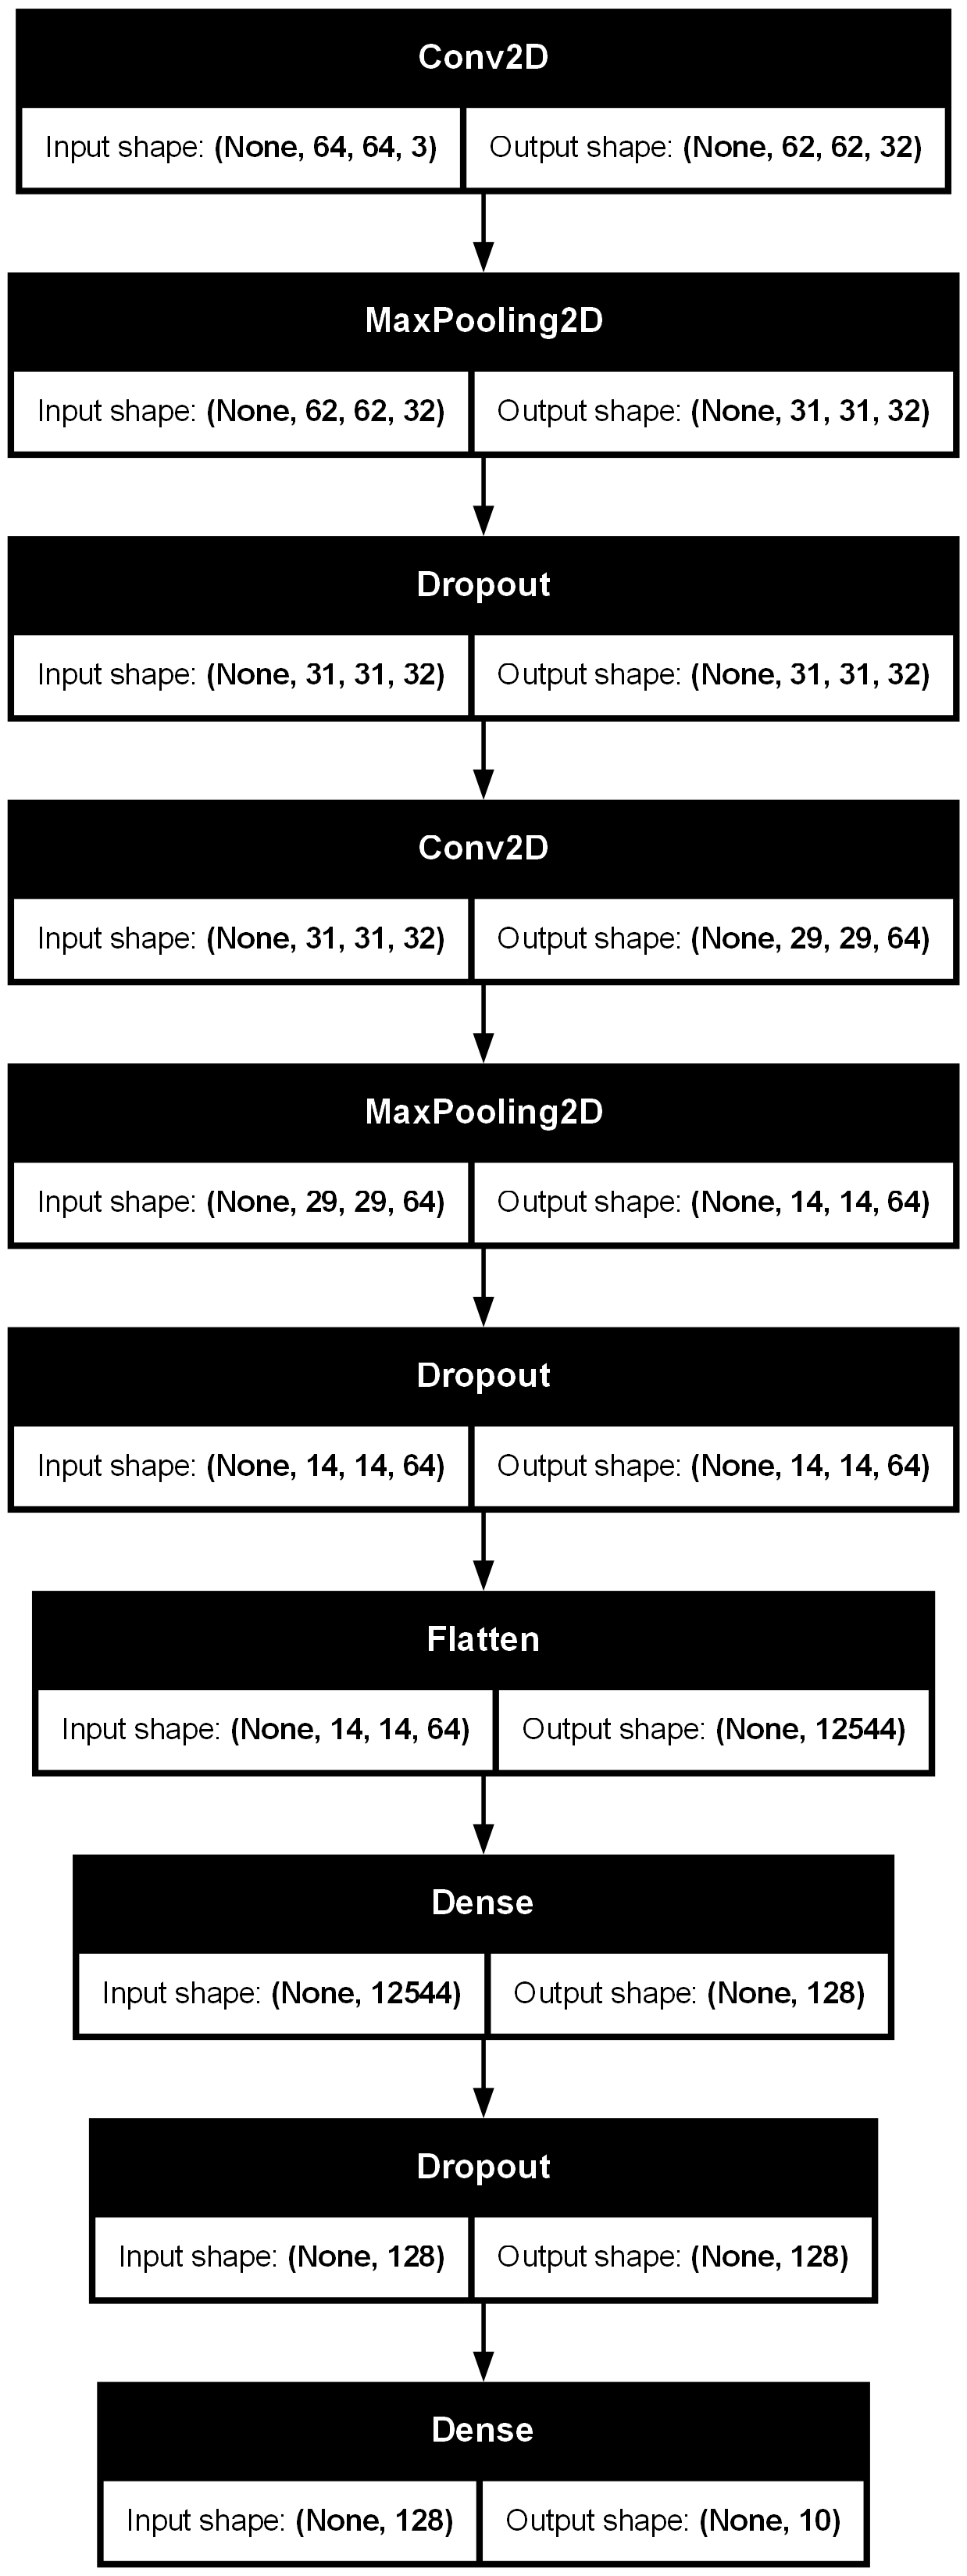

Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - accuracy: 0.3532 - loss: 1.6948 - val_accuracy: 0.4861 - val_loss: 1.3700
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.4864 - loss: 1.3454 - val_accuracy: 0.5269 - val_loss: 1.2643
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.5598 - loss: 1.2063 - val_accuracy: 0.6190 - val_loss: 1.0831
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.6131 - loss: 1.0852 - val_accuracy: 0.6425 - val_loss: 0.9391
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - accuracy: 0.6342 - loss: 1.0179 - val_accuracy: 0.6266 - val_loss: 1.0216
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.6560 - loss: 0.9681 - val_accuracy: 0.7018 - val_loss: 0.8389
Epoch 7/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - accuracy: 0.6730 - loss: 0.9107 - val_accuracy: 0.7177 - val_loss: 0.7714
Epoch 8/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.6912 - loss: 0.8766 - 

In [16]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

# RGB: bands 4,3,2 (index 3,2,1)
rgb_train = images_train[:, [3, 2, 1], :, :].astype(np.float32)
rgb_test = images_test[:, [3, 2, 1], :, :].astype(np.float32)
rgb_train = np.moveaxis(rgb_train, 1, -1) / rgb_train.max()  # (N,64,64,3)
rgb_test = np.moveaxis(rgb_test, 1, -1) / rgb_test.max()

model4 = Sequential(
    [
        Input(shape=(64, 64, 3)),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(10, activation="softmax"),
    ]
)

plot_model(model4, to_file="model4.png", show_shapes=True)
display(Image("model4.png"))

model4.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model4, show_shapes=True)
model4.fit(
    rgb_train,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(rgb_test, y_test_cat),
)
_, acc4 = model4.evaluate(rgb_test, y_test_cat)
print(f"CNN Accuracy: {acc4:.4f}")

#### 3.2.2 Advanced Model

Implement a fifth deep learning model targeting accuracy that will outperform all previous models. You are free to use any tools and techniques, including ensemble models and pre-trained models for transfer learning. Calculate classification accuracy on the test data. What specific tools or techniques did you choose to improve accuracy? Why did you select these approaches over others? Compare against previous models. Which model was the "best"? Why?

What are the two classes with the highest labeling error? Explain using data and showing mis-classified examples. Why do you think this is? Can you think of any strategies or approaches that might help to address this issue?

**Answer:** This fifth attempt at building a model utilizes a member of the Efficientnet model family, which was developed by Mingxing Tan and Quoc V. Le in 2019 in an attempt to [achieve](https://www.geeksforgeeks.org/computer-vision/efficientnet-architecture/#efficientnetb0-architecture-overview) "high performance with fewer computational resources compared to previous architectures." We utilize the EfficientNet-B0 model specifically pre-trained for image classification. Additional layers such as a GlobalAveragePooling2d layer (alternative to flattening that preserves spatial invariance) and an additional Dense/Dropout layer combination are included to attempt to adapt the pre-trained model to our specific dataset better. Theoretically, this combination of pre-trained and untrained models will help give this model added complexity and a leg-up compared to our prior models.

Unfortunately, this Model 5 turned out to be dramatically worse than previous models, beginning and ending at around 11% classification accuracy. This is likely a result of how the pre-trained weights and model size dominate the results, and the added layers were not sufficient to adapt the pre-trained model to our data. The top misidentified classes were relatively homogenous ones such as SeaLake and HerbaceousVegetation, which were often classified as residential (or vice-versa). Earlier models also tended to misclassify inherently noisy images (i.e. forest) as residential. This could possibly be addressed by increasing the size of the training set dramatically and/or augmenting it further. There is also the possibility that the pre-trained model was trained on images with a different resolution. Satellite imagery could be tiled to increase image resolution (though this would reduce the size of the dataset), or an alternative pre-trained model that was trained on similar-resolution images (or is resolution-insensitive) could be used.

In [17]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import confusion_matrix

base_model = EfficientNetB0(
    weights="imagenet", include_top=False, input_shape=(64, 64, 3)
)
base_model.trainable = False  # Freeze base

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
out = Dense(10, activation="softmax")(x)

model5 = Model(inputs=base_model.input, outputs=out)

model5.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model5.fit(
    rgb_train,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(rgb_test, y_test_cat),
)

_, acc5 = model5.evaluate(rgb_test, y_test_cat)
print(f"Transfer Learning Accuracy: {acc5:.4f}")

# Predict classes
y_pred5 = np.argmax(model5.predict(rgb_test), axis=1)

# Compute confusion matrix
cm5 = confusion_matrix(y_test_enc, y_pred5)

# Zero out diagonal (correct predictions)
np.fill_diagonal(cm5, 0)

# Flatten the confusion matrix and get indices of the top 2 largest values
flat_indices = np.argpartition(cm5.flatten(), -2)[-2:]  # top 2
# Sort these top 2 indices in descending order of confusion
flat_indices = flat_indices[np.argsort(cm5.flatten()[flat_indices])[::-1]]

# Convert flat indices to (true class, predicted class) pairs
top_pairs = [divmod(idx, cm5.shape[1]) for idx in flat_indices]

# Print the results
for i, (cls_true, cls_pred) in enumerate(top_pairs, 1):
    print(
        f"Top {i} confused pair: {CLASS_NAMES[cls_true]} → predicted as {CLASS_NAMES[cls_pred]}"
    )

Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 56s 166ms/step - accuracy: 0.1084 - loss: 2.3040 - val_accuracy: 0.1111 - val_loss: 2.2976
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 38s 148ms/step - accuracy: 0.1069 - loss: 2.2966 - val_accuracy: 0.1111 - val_loss: 2.2956
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.1068 - loss: 2.2955 - val_accuracy: 0.1111 - val_loss: 2.2950
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.1107 - loss: 2.2950 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.1046 - loss: 2.2950 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 42s 164ms/step - accuracy: 0.1104 - loss: 2.2949 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 7/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 41s 159ms/step - accuracy: 0.1056 - loss: 2.2950 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 8/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 41s 163ms/step - accuracy: 0.1077 - loss: 2

### 3.3 Multispectral Images

Apply your best model on multispectral images. You may use whichever image channels you wish, so long as you use more than just RGB (although you are not required to use any color channels). Calculate classification accuracy on the test data. Compare against results using RGB images.

How did adding multispectral channels impact your model's performance? Explain the role of additional spectral information in enhancing land cover classification.

**Answer:** The best model from our prior analysis was Model 4, with a classification accuracy of approximately 73%. All 13 bands from the multispectral datasest - covering shortwave blue, RGB, VNIR, and SWIR wavelengths - could provide additional information relevant to specific land cover types and were thus included in this analysis. This additional data helped this model achieve a classification accuracy of about 87%. This additional spectral data most likely helped differentiate certain features that are difficult to distinguish with RGB alone (i.e. different types of vegetation, which produce different VNIR and SWIR signatures).

In [18]:
ms_train_13 = np.moveaxis(images_train, 1, -1).astype(np.float32)
ms_test_13 = np.moveaxis(images_test, 1, -1).astype(np.float32)

# normalize band values from 0-1
ms_train_13 /= ms_train_13.max()
ms_test_13 /= ms_test_13.max()

model4_ms = Sequential(
    [
        Input(shape=(64, 64, 13)),
        Conv2D(32, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(10, activation="softmax"),
    ]
)

model4_ms.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)
model4_ms.fit(
    ms_train_13,
    y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(ms_test_13, y_test_cat),
)

_, acc4_ms = model4_ms.evaluate(ms_test_13, y_test_cat)
print(f"Model 4 on all multispectral bands accuracy: {acc4_ms:.4f}")

Epoch 1/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.5202 - loss: 1.3304 - val_accuracy: 0.6544 - val_loss: 0.9331
Epoch 2/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6899 - loss: 0.8852 - val_accuracy: 0.7703 - val_loss: 0.6676
Epoch 3/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - accuracy: 0.7490 - loss: 0.7432 - val_accuracy: 0.7697 - val_loss: 0.6505
Epoch 4/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.7749 - loss: 0.6541 - val_accuracy: 0.8335 - val_loss: 0.4966
Epoch 5/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.7988 - loss: 0.6037 - val_accuracy: 0.8260 - val_loss: 0.4889
Epoch 6/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8123 - loss: 0.5553 - val_accuracy: 0.8170 - val_loss: 0.5564
Epoch 7/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.8198 - loss: 0.5337 - val_accuracy: 0.8626 - val_loss: 0.4286
Epoch 8/15
254/254 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.8380 - loss: 0.4910 - 

## 4. Reflection Questions

What are your takeaways from tuning the parameters of the different models? What are your observations about increasing the number of training epochs? Did you run into any challenges or limitations when doing this? What was the impact of using dropout? How did the ensemble models compare to the other models? What kinds of challenges or limitations did you encounter when preparing and training the models for this assignment, and how might you address them in the future? How might you apply what you've learned about model tuning, dropout, and data processing to a different deep learning problem?

* Parameter tuning can improve models slightly, but overfitting is often a concern and strong performance gains that result in generalizability can often only be accomplished by changing the structure of the model itself.
* Increasing the number of epochs often helped to stabilize prediction accuracy, but there was a sweet spot between under- and overfitting around 10-15 epochs.
* Dropout managed to marginally increase the accuracy of our initial Neural Network models, but only when the dropout rate was tuned to approximately 0.3. It is possible that this dataset is not large enough to benefit much from dropout.
* Our ensemble model did not perform any better compared to the initial NN models, despite possibly reducing variance in predictions.
* Some challenges and limitations we encountered included:
    * Training Time: tweaking and re-running models that take over 10 minutes to run grew increasingly frustrating
    * Pre-Trained Model Choice: despite utilizing a pre-trained model in the hopes of improving predictions, choosing one compatible with our training dataset or that provided substantial benefits over simpler model architectures turned out to be far more difficult than we expected.
    * Parameter Tweaking Permutations: it was often hard to determine what combinations of parameters would produce the best outcome. Between Epoch count, node count, hidden layer depths, and combinations of dropout layers/rates, the more complex models became increasingly laborious to tune.
* Spatially-aware deep learning methods such as CNNs are far more apt for classifying spatial imagery, and dropout appears to be a crucial component for models of this complexity. We also determined that additional bands beyond RGB helped improve classification significantly, emphasizing the importance of domain knowledge for selecting useful bands.